# Customer Churn Prediction

# Sprint 3 : Exploratory Data Analysis (EDA)

---

## Objective

The goal of this notebook is to understand the distribution of features, identify potential data quality issues, discover relationships between variables, and generate business insights before building machine learning models.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv('../data/raw/Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Dataset Shape

Checking the number of rows and columns in the dataset.

In [4]:
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows    : 10000
Columns : 14


# Statistical Summary

Generating descriptive statistics for numerical features.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
RowNumber,10000.0,5.000500e+03,2886.895680,1.00,2500.75,5.000500e+03,7.500250e+03,10000.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


## Observations

- All numerical features contain 10,000 observations, indicating no missing values.

- The average customer age is approximately 39 years.

- Customer ages range from 18 to 92 years.

- Customer credit scores range from 350 to 850.

- Customer tenure ranges between 0 and 10 years.

- Some customers have zero account balance, which will be investigated further.Since the 25th percentile is also 0, a significant portion of customers appear to maintain zero account balance.

- Estimated salaries vary widely across customers.

- Balance and EstimatedSalary show high variability compared to other numerical features.

- Binary features include HasCrCard, IsActiveMember and Exited.

- Age may contain potential outliers and will be analyzed further using boxplots.

In [6]:
df.describe(include="object").T

C:\Users\DUBAI LAPTOP BAZAR\AppData\Local\Temp\ipykernel_26788\1274302342.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object").T


,count,unique,top,freq
Surname,10000,2932,Smith,32
Geography,10000,3,France,5014
Gender,10000,2,Male,5457


## Observations

- There are **3 categorical features** in the dataset: **Surname, Geography, and Gender**.

- **Geography** contains **3 unique values**, representing three different countries.

- **Gender** contains **2 unique values**, indicating two categories: Male and Female.

- **Surname** contains **2,932 unique values**, making it the feature with the highest number of unique categories.

- **Surname** Surname is a high-cardinality categorical feature with 2,932 unique values. It is likely to have limited predictive power for customer churn and may introduce unnecessary complexity during encoding. This feature will be evaluated and potentially removed during the preprocessing stage.

### Possible Impact on ML

- Surname may be removed.

- Geography requires encoding.

- Balance may require scaling.

- Age may contain outliers.

- Target is slightly imbalanced.

# Target Variable Analysis

The target variable is **Exited**.

- 0 → Customer Stayed
- 1 → Customer Churned

In this section, we will analyze the distribution of the target variable.

In [7]:
#count of each class
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [8]:
#Percentage of each class
(df['Exited'].value_counts(normalize = True)*100).round(2)

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

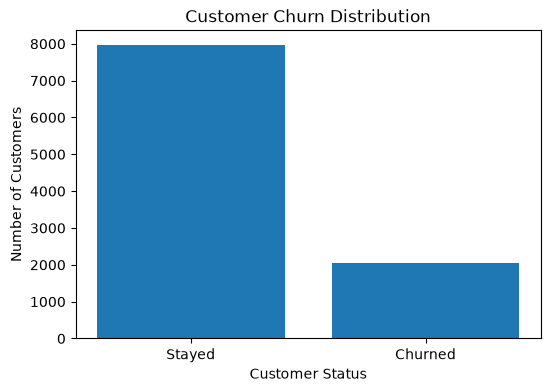

In [9]:
import matplotlib.pyplot as plt

churn_counts = df["Exited"].value_counts()

plt.figure(figsize=(6,4))

plt.bar(
    ["Stayed", "Churned"],
    churn_counts.values
)

plt.title("Customer Churn Distribution")
plt.xlabel("Customer Status")
plt.ylabel("Number of Customers")

plt.show()

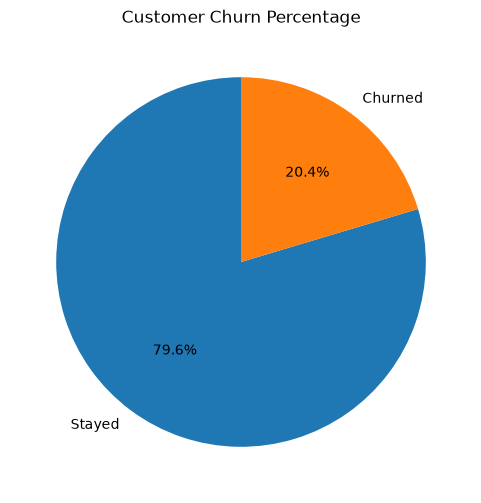

In [10]:
plt.figure(figsize=(6,6))

plt.pie(
    churn_counts,
    labels=["Stayed", "Churned"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Customer Churn Percentage")

plt.show()

## Statistical Insights
- Total customers 10000

- Customers who stayed: 7963 (79.63%)

- Customers who churned: 2037 (20.63%)

- Churn rate: 20.4%

- Majority class: stayed

---

## Business Insights

- Most customers continue using the bank's services.

- Around 20.4% customers have churned.

- The dataset shows moderate class imbalance.

- Although the majority of customers remain with the bank, approximately one out of every five customers has churned. Reducing this churn rate could significantly improve customer retention and business revenue.

---

## Possible Impact on ML

- Accuracy alone may not be a reliable evaluation metric.

- Precision, Recall and F1-score should also be considered.

- Stratified train-test split should be used to preserve class distribution.

- Class imbalance should be considered while selecting evaluation metrics and model validation strategies.


## Visualization Review
- The class distribution is moderately imbalanced but not severely skewed. Classical machine learning algorithms such as Logistic Regression, Decision Tree, KNN, and Naive Bayes can still be trained without immediate resampling. However, model performance should be evaluated using multiple metrics beyond accuracy.

## Key Takeaways

- Churn rate is approximately 20%.

- Most customers remain with the bank.

- Dataset is moderately imbalanced.

- Stratified train-test split is recommended.

- F1-score should be considered during evaluation.

In [17]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='str')

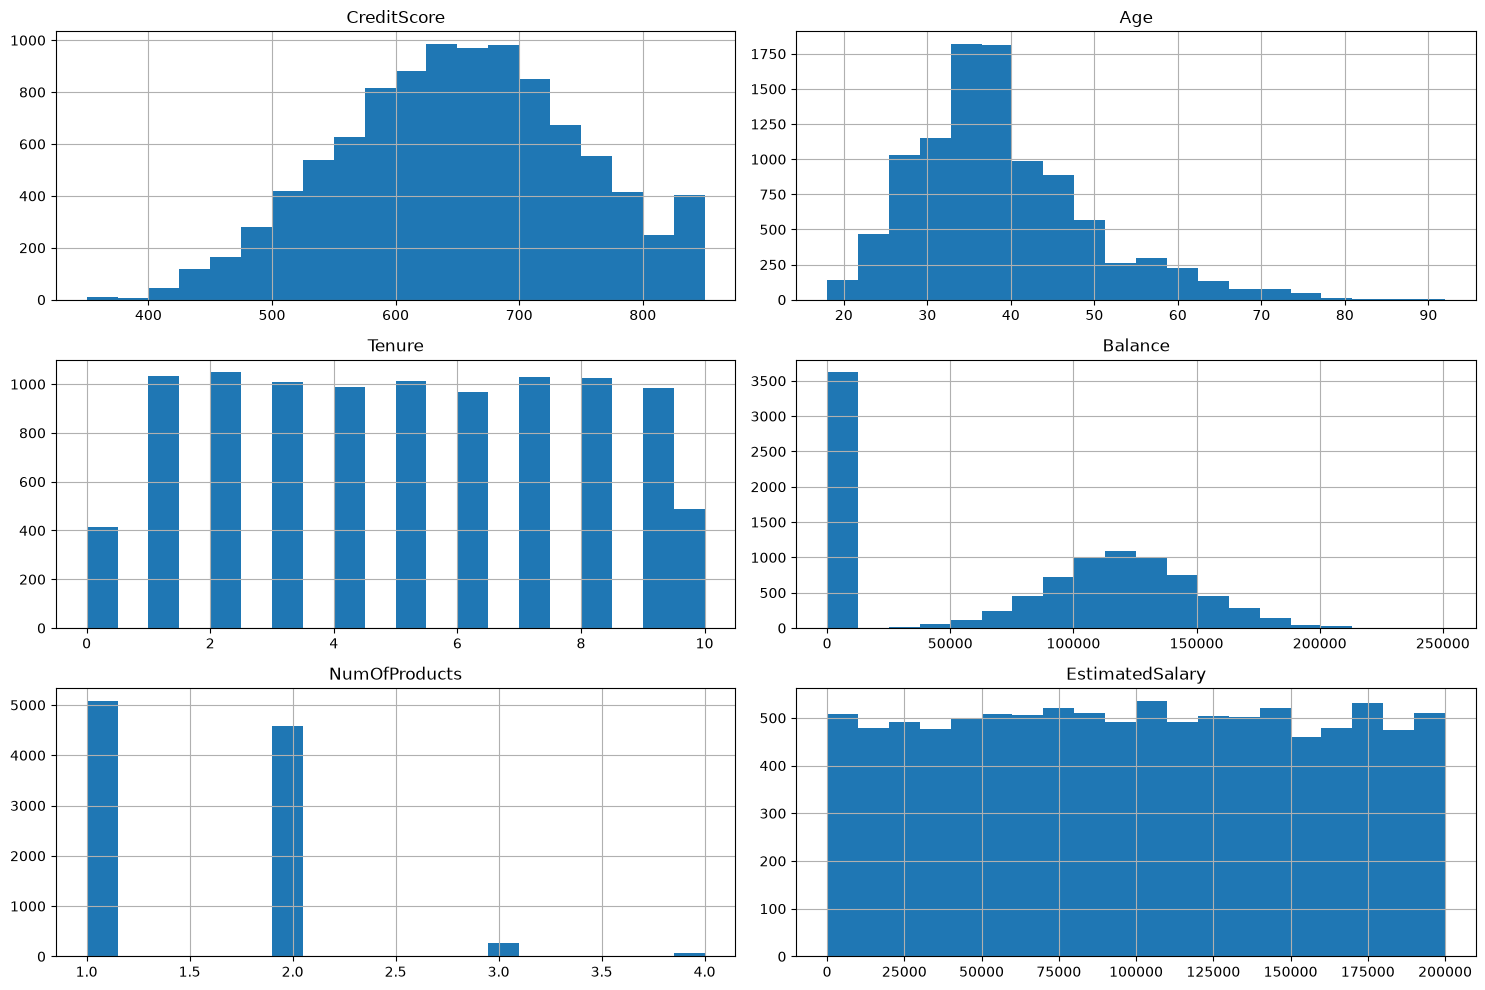

In [18]:
numerical_features = [
    "CreditScore",
    "Age",
    "Tenure",
    "Balance",
    "NumOfProducts",
    "EstimatedSalary"
]

df[numerical_features].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

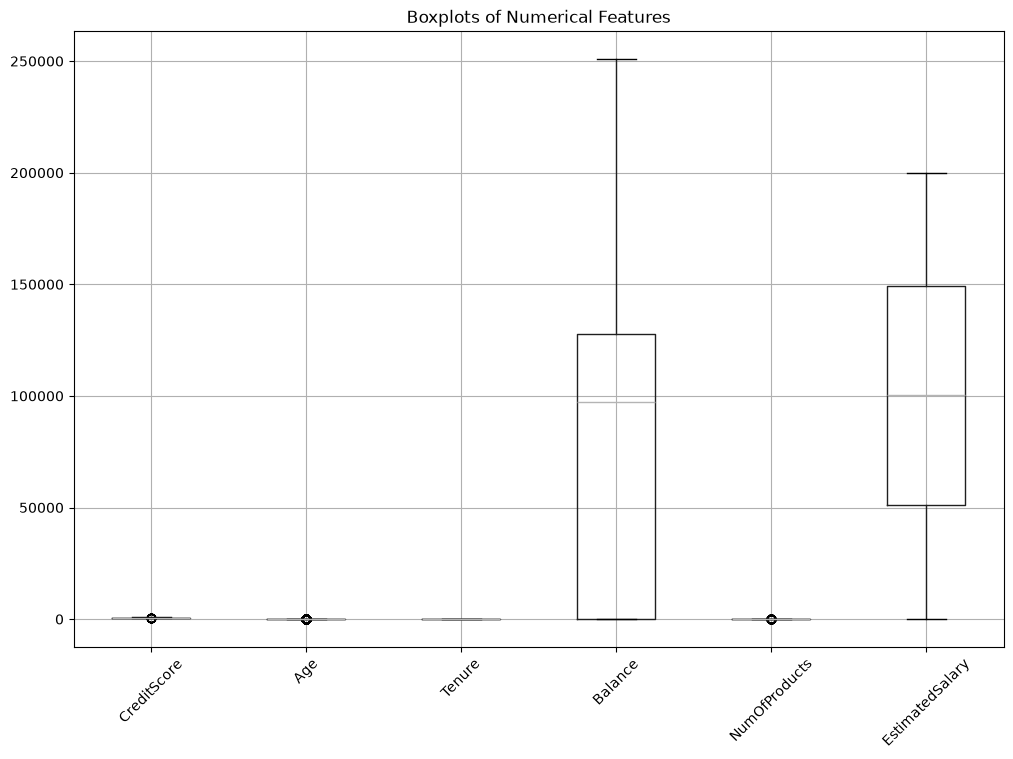

In [19]:
plt.figure(figsize=(12,8))

df[numerical_features].boxplot()

plt.title("Boxplots of Numerical Features")

plt.xticks(rotation=45)

plt.show()

## Numerical Feature Insights

- Age appears to contain several outliers.

- Balance contains a large number of zero values.

- EstimatedSalary is distributed almost uniformly.

- CreditScore follows an approximately normal distribution.

- Tenure ranges from 0 to 10 years without significant skewness.

- NumOfProducts is concentrated around 1 and 2 products.

### Possible Impact on ML

- Age outliers will be investigated but not removed immediately.

- Balance may require further analysis due to many zero values.

- Numerical features have different scales, so feature scaling will be required for distance-based algorithms such as KNN and Logistic Regression.

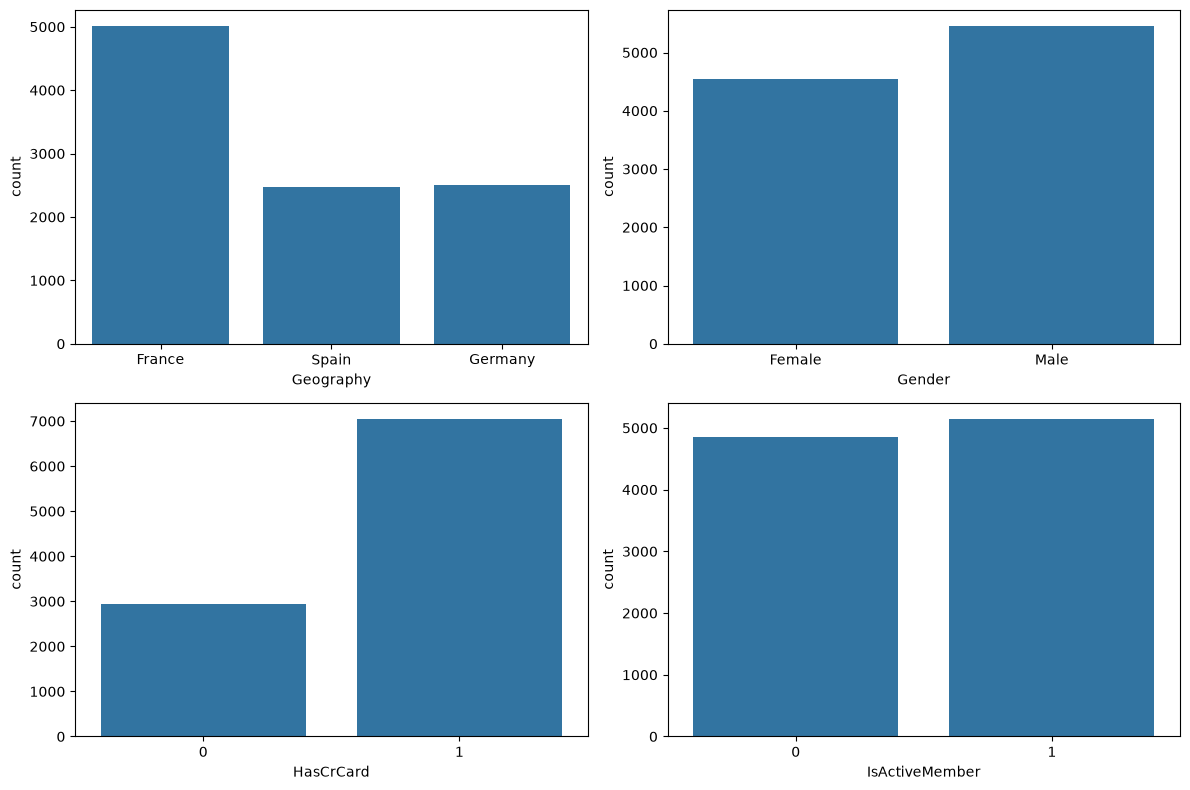

In [20]:
categorical_features = [
    "Geography",
    "Gender",
    "HasCrCard",
    "IsActiveMember"
]

fig, axes = plt.subplots(2,2, figsize=(12,8))

for ax, feature in zip(axes.flatten(), categorical_features):
    sns.countplot(
        data=df,
        x=feature,
        ax=ax
    )

plt.tight_layout()

plt.show()

## Categorical Feature Insights

- Most customers are from France.

- The dataset contains slightly more male customers than female customers.

- Around 70% of customers own a credit card.

- Active and inactive customers are almost equally distributed.

### Possible Impact on ML

- Geography and Gender require encoding.

- HasCrCard and IsActiveMember are already binary and do not require encoding.

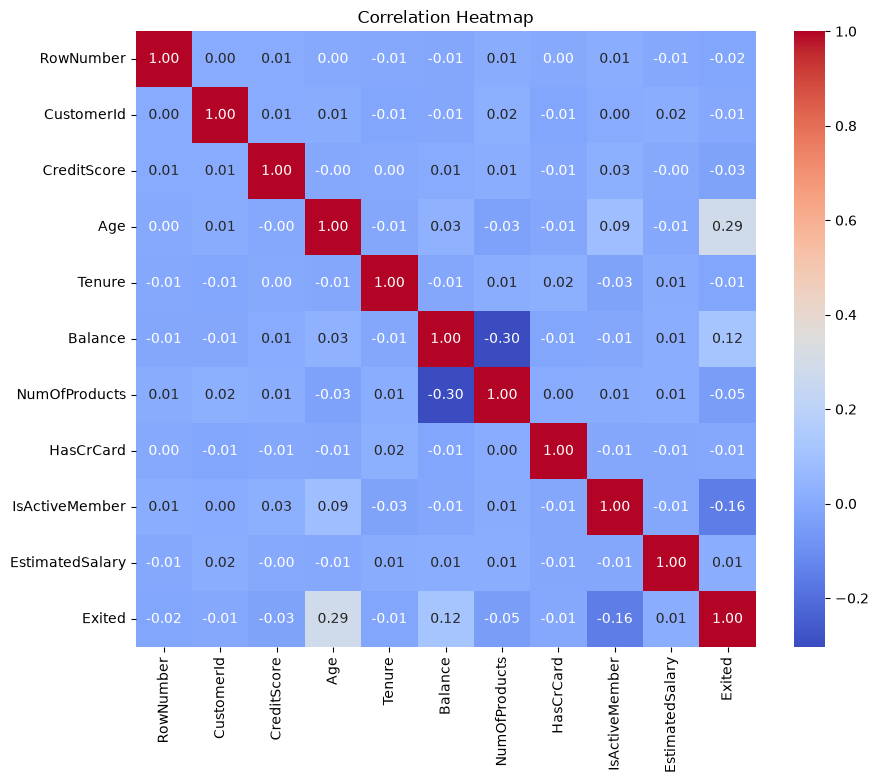

In [22]:
plt.figure(figsize=(10,8))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

## Correlation Insights

- Most numerical features show weak correlation with each other.

- Age has a moderate positive correlation with Exited.

- IsActiveMember has a moderate negative correlation with Exited.

- No strong multicollinearity is observed among the numerical features.

### Possible Impact on ML

- Feature scaling will be necessary.

- No feature needs to be removed due to multicollinearity at this stage.

# Final EDA Summary

## Key Findings

- The dataset contains 10,000 customer records.

- No missing values are present.

- No duplicate rows are present.

- The target variable is moderately imbalanced (20.37% churn rate).

- Age contains potential outliers.

- Balance includes many zero values.

- Geography and Gender require encoding.

- Numerical features have different scales.

- CustomerId, RowNumber and Surname are identifier/high-cardinality features and are unlikely to improve prediction.

## Conclusion

The dataset is clean and well-structured. It is now ready for preprocessing, feature engineering, and machine learning model development.